<a href="https://colab.research.google.com/github/luwry2/TFM/blob/Quercus/Clasifiaci%C3%B3n_Quercus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **TFM: CLASIFICACIÓN DE IMÁGENES DE QUERCUS EN LA PROVINCIA DE ALBACETE**

Autora: Lucía Cano Navarro

Máster Big Data, Data Science & Inteligencia Artificial 2024-2025

INFORMACIÓN IMPORTANTE

Este notebook utiliza un dataset subido a Kaggle y ha sido trabajado en Google Colab. El código en cuanto al acceso a la API de Kaggle es diferente si se trabaja en Google Colab o si se trabaja en Jupyter u otro entorno local. Por ello, para uso en local el acceso a Kaggle sería diferente.  

En Jupyter u otro entorno local de Windows, el archivo json debe estar en la carpeta C:\Users\tu-usuario\/.kaggle. En sistemas operativos como Linux o macOS, la ruta sería ~/.kaggle/
En Google Colab, el archivo kaggle.json debe ser subido directamente a la sesión de Colab

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision.datasets import ImageFolder
from transformers import AutoImageProcessor, ResNetForImageClassification
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
from tqdm import tqdm
import os
import shutil
import time
import torch.nn.functional as F

Para la ejecución de este trabajo de manera ágil ha sido necesario acudir a GPU, de lo contrario, solo con CPU supone unos tiempos de ejecución demasiado largos.

In [2]:
# Configuración del dispositivos GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando el dispositivo: {device}")

Usando el dispositivo: cuda


## Preparación del dataset

Como se comentaba en la nota del principio, es necesario asegurarse de haber subido el archivo kaggle.json al entorno de Colab para poder descargar el dataset

In [3]:
# Conectamos Google Colab con Kaggle y descargamos el Dataset

try:
    os.makedirs('/root/.kaggle', exist_ok=True)
    shutil.copyfile('kaggle.json', '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print("Kaggle API key configurada.")
except FileNotFoundError:
    print("Error: kaggle.json no encontrado. Por favor, sube tu archivo API Key de Kaggle.")
    exit()

# Ruta del dataset en Kaggle
DATASET_NAME = 'lucano05/dataset-hojas-quercus'

# Nombre de la carpeta descomprimida
EXTRACTED_FOLDER_NAME = DATASET_NAME.split("/")[-1]
DATA_DIR = os.path.join(os.getcwd(), EXTRACTED_FOLDER_NAME)

# Si no existe, descargamos y descomprimimos el dataset
if not os.path.exists(DATA_DIR):
    print(f"Descargando dataset: {DATASET_NAME}")
    os.system(f'kaggle datasets download -d {DATASET_NAME}')
    zip_path = f'{EXTRACTED_FOLDER_NAME}.zip'
    if os.path.exists(zip_path):
        shutil.unpack_archive(zip_path, EXTRACTED_FOLDER_NAME)

# Verificamos la ruta del dataset
if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"El directorio de datos '{DATA_DIR}' no existe.")


Kaggle API key configurada.
Descargando dataset: lucano05/dataset-hojas-quercus


A continuación vamos a establecer dos parámetros constantes que no van a variar a lo largo del proceso de ajuste del modelo: el número de clases a clasificar y la semilla.

In [4]:
# Vamos a clasificar 5 tipos de árboles
NUM_CLASSES = 5

# Semilla
SEED = 42

A continuación vamos a realizar la carga de los datos y a dividirlos en 3 conjuntos: entrenamiento (80% de los datos), validación (10%) y prueba (10%)

In [5]:
# Cargamos el dataset completo de la carpeta
full_dataset = ImageFolder(root=DATA_DIR)
class_names = full_dataset.classes
print(f"Clases encontradas: {class_names}")

# Comprobamos si el número de clases encontradas es el correcto
if len(class_names) != NUM_CLASSES:
    raise ValueError(f"El número de clases encontrado ({len(class_names)}) no coincide con el esperado ({NUM_CLASSES}).")
print(f"Número total de clases: {NUM_CLASSES}")

# Calculamos los tamaños de los conjuntos de datos
total_size = len(full_dataset)
train_size = int(0.8 * total_size)
val_size = int(0.1 * total_size)
test_size = total_size - train_size - val_size

# Dividimos el dataset en 3 conjuntos: entrenamiento, validación y prueba
train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(SEED)
)

print(f"Número de imágenes en el conjunto de entrenamiento: {len(train_dataset)}")
print(f"Número de imágenes en el conjunto de validación: {len(val_dataset)}")
print(f"Número de imágenes en el conjunto de prueba: {len(test_dataset)}")


Clases encontradas: ['Alcornoque', 'Coscoja', 'Encina', 'Melojo', 'Quejigo']
Número total de clases: 5
Número de imágenes en el conjunto de entrenamiento: 4000
Número de imágenes en el conjunto de validación: 500
Número de imágenes en el conjunto de prueba: 500


## Preparación modelo pre-entrenado

Vamos a realizar la carga del modelo y el procesador de Hugging Face y la definición de los parámetros del modelo. Estos parámetros se han ido ajustando a lo largo del proceso de entrenamiento hasta optener los resultados óptimos.

In [6]:
# Cargamos el procesador y el modelo de Hugging Face
# Vamos a reemplazar la capa de salida con una nueva capa lineal con 5 neuronas
processor = AutoImageProcessor.from_pretrained("microsoft/resnet-50")
model = ResNetForImageClassification.from_pretrained(
    "microsoft/resnet-50",
    num_labels=NUM_CLASSES,
    ignore_mismatched_sizes=True
)
model.to(device)

# Parámetros del modelo
BATCH_SIZE = 32 # Como trabajamos con GPU, podemos poner un número grande de imágenes procesadas por iteración
LEARNING_RATE = 5e-5
EPOCHS = 10
PATIENCE = 5 # Número de épocas a esperar si la precisión de validación no mejora
MIN_DELTA = 0.01 # Cambio mínimo para ser considerado una mejora


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

preprocessor_config.json:   0%|          | 0.00/266 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

Some weights of ResNetForImageClassification were not initialized from the model checkpoint at microsoft/resnet-50 and are newly initialized because the shapes did not match:
- classifier.1.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([5]) in the model instantiated
- classifier.1.weight: found shape torch.Size([1000, 2048]) in the checkpoint and torch.Size([5, 2048]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


A continuación se va a aplicar data augmentation al conjunto de entrenamiento con el objetivo de aumentar el tamaño y la diversidad del conjunto de entrenamiento

In [7]:
# Definimos las transformaciones y DataLoaders

from torchvision import transforms

# Transformaciones para el conjunto de entrenamiento (con data augmentation)
train_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Transformaciones para validación y prueba (sin data augmentation)
val_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=processor.image_mean, std=processor.image_std)
])

# Aplicamos las transformaciones a los datasets
train_dataset.dataset.transform = train_transforms
val_dataset.dataset.transform = val_transforms
test_dataset.dataset.transform = val_transforms

# Creamos los DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

## Entrenamiento

Realizamos a continuación el entrenamiento del modelo con los parámetros anteriormente definidos.

Mencionar que se ha incluido el mecanismo de Early Stopping para evitar posibles sobreajustes.

In [31]:
# Definimos el optimizador y la función de pérdida
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

# Parámetros para Early Stopping
best_val_accuracy = 0
patience_counter = 0
MODEL_PATH = 'quercus_model.pth'

# Historial para las gráficas
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

# Bucle principal de entrenamiento
start_time = time.time()
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    # Incluimos barra de progreso en el bucle de entrenamiento
    with tqdm(train_loader, desc=f"Época {epoch+1}/{EPOCHS} Entrenamiento") as pbar:
        for images, labels in pbar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images).logits
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            pbar.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_dataset)
    train_acc = correct / total
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)

    # Validación
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0
    with torch.no_grad():
        # Bucle de validación con barra de progreso
        with tqdm(val_loader, desc=f"Época {epoch+1}/{EPOCHS} Validación") as pbar:
            for images, labels in pbar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images).logits
                loss = criterion(outputs, labels)

                val_loss += loss.item() * images.size(0)

                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                pbar.set_postfix(loss=loss.item())

    val_accuracy = val_correct / val_total
    val_loss /= len(val_dataset)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_accuracy)

    print(f"Época {epoch+1}: Pérdida de Entrenamiento: {train_loss:.4f}, Precisión de Entrenamiento: {train_acc*100:.2f}%, Pérdida de Validación: {val_loss:.4f}, Precisión de Validación: {val_accuracy*100:.2f}%")

    # Learly Stopping
    if val_accuracy > best_val_accuracy + MIN_DELTA:
        best_val_accuracy = val_accuracy
        patience_counter = 0
        # Guardamos el mejor modelo
        try:
            torch.save(model.state_dict(), MODEL_PATH)
            print(f"Modelo guardado exitosamente en: {MODEL_PATH}")
        except Exception as e:
            print(f"Error al guardar el modelo: {e}")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"Parada anticipada en la época {epoch+1} debido a que la precisión de validación no ha mejorado.")
            break

end_time = time.time()
total_time = end_time - start_time
total_time_minutes = total_time / 60.0
print("Entrenamiento finalizado.")
print(f"Tiempo total del entrenamiento: {total_time:.2f} segundos ({total_time_minutes:.2f} minutos)")


Época 1/10 Validación: 100%|██████████| 16/16 [00:15<00:00,  1.07it/s, loss=0.02]


Época 1: Pérdida de Entrenamiento: 0.0523, Precisión de Entrenamiento: 98.88%, Pérdida de Validación: 0.0657, Precisión de Validación: 97.80%
Modelo guardado exitosamente en: quercus_model.pth


Época 2/10 Validación: 100%|██████████| 16/16 [00:14<00:00,  1.08it/s, loss=0.0115]


Época 2: Pérdida de Entrenamiento: 0.0368, Precisión de Entrenamiento: 99.12%, Pérdida de Validación: 0.0565, Precisión de Validación: 98.00%


Época 3/10 Validación: 100%|██████████| 16/16 [00:15<00:00,  1.05it/s, loss=0.00868]


...

Época 4: Pérdida de Entrenamiento: 0.0244, Precisión de Entrenamiento: 99.58%, Pérdida de Validación: 0.0575, Precisión de Validación: 98.00%


Época 5/10 Validación: 100%|██████████| 16/16 [00:14<00:00,  1.08it/s, loss=0.00563]


Época 5: Pérdida de Entrenamiento: 0.0201, Precisión de Entrenamiento: 99.50%, Pérdida de Validación: 0.0598, Precisión de Validación: 98.00%


Época 6/10 Validación: 100%|██████████| 16/16 [00:15<00:00,  1.06it/s, loss=0.00476]

Época 6: Pérdida de Entrenamiento: 0.0175, Precisión de Entrenamiento: 99.67%, Pérdida de Validación: 0.0539, Precisión de Validación: 98.20%
Parada anticipada en la época 6 debido a que la precisión de validación no ha mejorado.
Entrenamiento finalizado.
Tiempo total del entrenamiento: 777.46 segundos (12.96 minutos)


## Análisis de resultados

A continuación, no solo vamos a analizar métricas como la precisión, sino que también queremos analizar "la confianza". Es decir,  que también indique cuán seguro está de la predicción.

In [9]:
# Realizamos la evalución sobre el conjunto de prueba y verificamos el nivel de confianza

from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Umbral de confianza
CONFIDENCE_THRESHOLD = 0.8

# Cargamos el mejor modelo guardado para la evaluación
try:
    model.load_state_dict(torch.load(MODEL_PATH))
except FileNotFoundError:
    print("\nEl archivo del modelo no se encontró. Usando el último modelo entrenado.")

model.eval()
test_correct = 0
test_total = 0
all_preds = []
all_labels = []
misclassified_images = []
low_confidence_count = 0

print("\n--- Evaluación detallada de cada imagen en el conjunto de prueba ---")
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).logits

        # Obtenemos las probabilidades (confianza) usando Softmax
        probabilities = F.softmax(outputs, dim=1)
        max_prob, predicted = torch.max(probabilities, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        # Comparamos las predicciones con etiquetas reales
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        for i in range(len(labels)):
            pred_class = class_names[predicted[i]]
            true_class = class_names[labels[i]]
            confidence = max_prob[i].item() * 100

            if confidence >= CONFIDENCE_THRESHOLD * 100:
                print(f"Imagen: {test_total-len(labels)+i+1} - Real: '{true_class}', Predicción: '{pred_class}' con {confidence:.2f}% de confianza.")
            else:
                print(f"Imagen: {test_total-len(labels)+i+1} - Real: '{true_class}', el modelo no está seguro de cómo clasificar esta imagen (confianza: {confidence:.2f}%).")
                low_confidence_count += 1

            # Almacenammos las imágenes mal clasificadas para la posterior visualización
            if predicted[i] != labels[i]:
                mean = np.array(processor.image_mean)
                std = np.array(processor.image_std)
                image_np = (images[i].cpu().numpy().transpose(1, 2, 0) * std + mean)
                image_np = np.clip(image_np, 0, 1)

                misclassified_images.append({
                    'image': image_np,
                    'true_label': true_class,
                    'predicted_label': pred_class
                })


--- Evaluación detallada de cada imagen en el conjunto de prueba ---
Imagen: 1 - Real: 'Quejigo', Predicción: 'Quejigo' con 85.13% de confianza.
Imagen: 2 - Real: 'Encina', Predicción: 'Encina' con 99.56% de confianza.
Imagen: 3 - Real: 'Encina', Predicción: 'Encina' con 99.34% de confianza.
Imagen: 4 - Real: 'Encina', Predicción: 'Encina' con 99.61% de confianza.
Imagen: 5 - Real: 'Coscoja', Predicción: 'Coscoja' con 98.67% de confianza.
Imagen: 6 - Real: 'Coscoja', Predicción: 'Coscoja' con 99.79% de confianza.
Imagen: 7 - Real: 'Encina', Predicción: 'Encina' con 99.00% de confianza.
Imagen: 8 - Real: 'Alcornoque', Predicción: 'Alcornoque' con 99.37% de confianza.
Imagen: 9 - Real: 'Coscoja', Predicción: 'Coscoja' con 95.08% de confianza.
Imagen: 10 - Real: 'Encina', Predicción: 'Encina' con 90.66% de confianza.
Imagen: 11 - Real: 'Coscoja', Predicción: 'Coscoja' con 99.88% de confianza.
Imagen: 12 - Real: 'Quejigo', Predicción: 'Quejigo' con 99.92% de confianza.
Imagen: 13 - Real: 

In [10]:
# Calculamos el porcentaje de imágenes con baja confianza
low_confidence_percentage = (low_confidence_count / test_total) * 100 if test_total > 0 else 0
print(f"\nPorcentaje de imágenes con confianza inferior a {CONFIDENCE_THRESHOLD*100:.0f}%: {low_confidence_percentage:.2f}%")


Porcentaje de imágenes con confianza inferior a 80%: 5.80%


In [11]:
test_accuracy = 100 * test_correct / test_total
print(f"\nPrecisión total en el conjunto de prueba: {test_accuracy:.2f}%")

# Reporte de clasificación
print("\nReporte de clasificación")
print(classification_report(all_labels, all_preds, target_names=class_names))


Precisión total en el conjunto de prueba: 98.60%

Reporte de clasificación
              precision    recall  f1-score   support

  Alcornoque       0.96      0.99      0.97        89
     Coscoja       0.99      0.99      0.99       101
      Encina       0.99      0.96      0.98       111
      Melojo       1.00      0.99      0.99        98
     Quejigo       0.99      1.00      1.00       101

    accuracy                           0.99       500
   macro avg       0.99      0.99      0.99       500
weighted avg       0.99      0.99      0.99       500



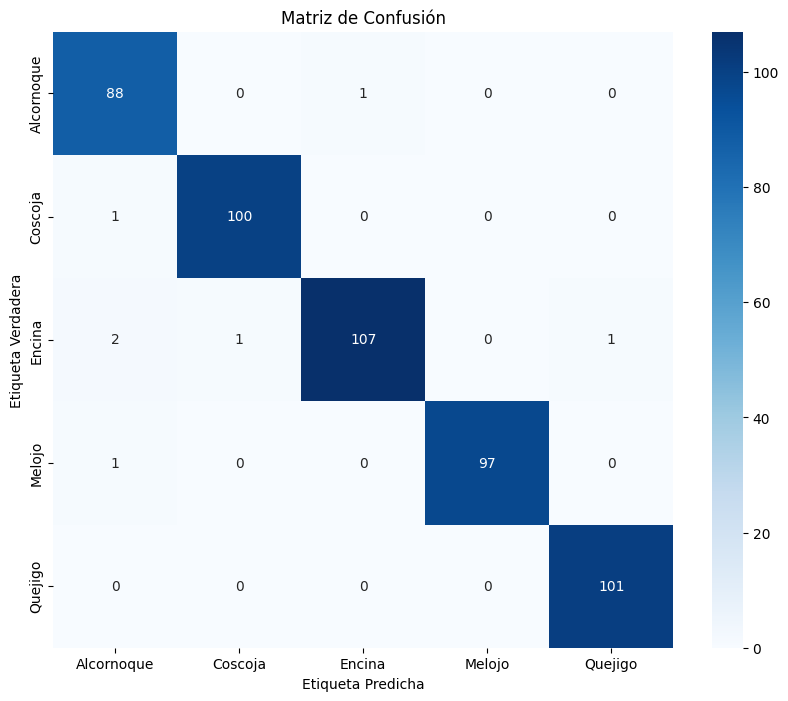

In [12]:
# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.show()

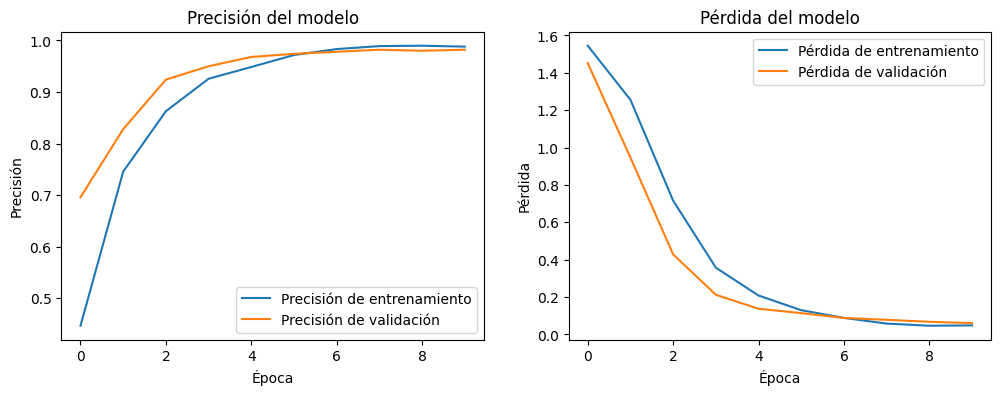

In [13]:
# Gráficas de precisión y pérdida
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Precisión de entrenamiento')
plt.plot(history['val_acc'], label='Precisión de validación')
plt.title('Precisión del modelo')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Pérdida de entrenamiento')
plt.plot(history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida del modelo')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.show()


Imágenes clasificadas de forma errónea


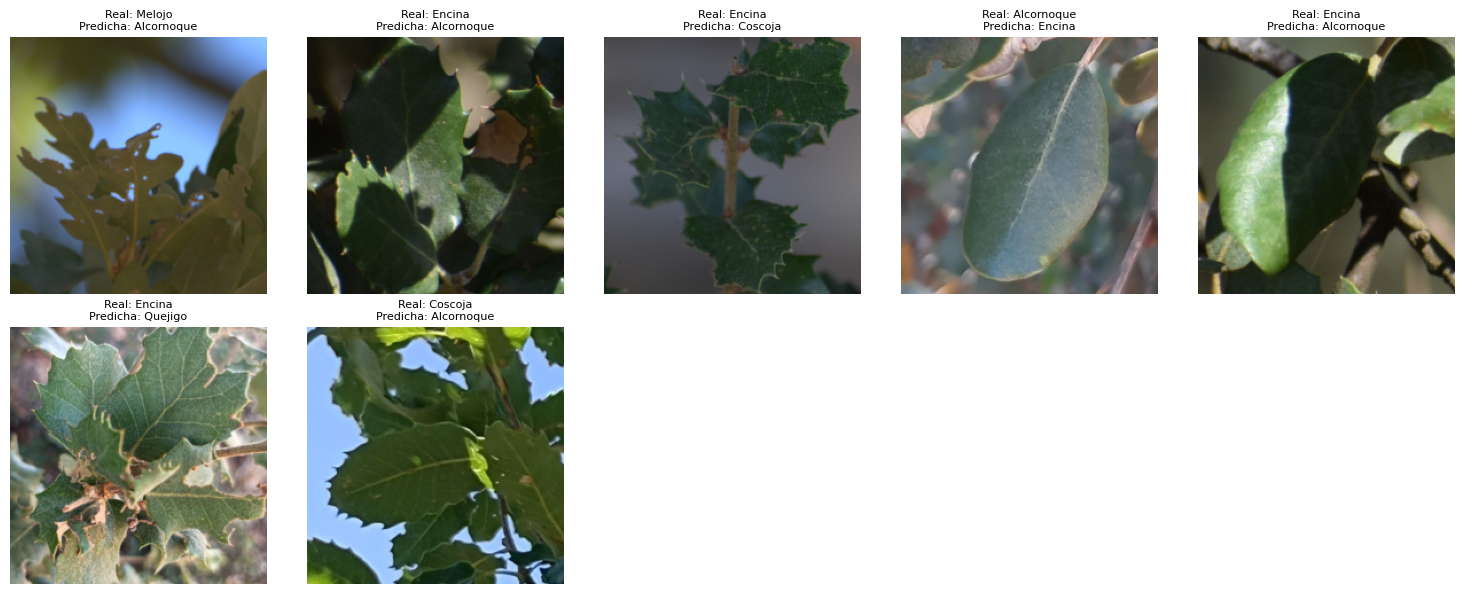

In [14]:

# Mostramos las imágenes mal clasificadas
print("\nImágenes clasificadas de forma errónea")
if len(misclassified_images) == 0:
    print("No se han encontrado imágenes mal clasificadas")
else:
    num_to_show = min(len(misclassified_images), 20)
    fig, axes = plt.subplots(int(np.ceil(num_to_show/5)), 5, figsize=(15, 3*int(np.ceil(num_to_show/5))))
    axes = axes.flatten()

    for i in range(num_to_show):
        ax = axes[i]
        img_info = misclassified_images[i]
        ax.imshow(img_info['image'])
        ax.set_title(f"Real: {img_info['true_label']}\nPredicha: {img_info['predicted_label']}", fontsize=8)
        ax.axis('off')

    for j in range(num_to_show, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


## Prueba de uso

Ejemplo de uso del modelo guardado para predicción en una imagen individual

In [32]:
def predict_image(image_path):
    """
    DESCRIPCIÓN:
    Carga y preprocesa una imagen, luego usa el modelo para predecir su clase.

    PARÁMETROS:
    image_path : ruta del archivo de la imagen a clasificar.


    RETURN:
    predicted_class_name : nombre de la clase predicha.
    confidence : nivel de confianza de la predicción.

    """

    try:
        # Cargamos la imagen
        image = Image.open(image_path).convert("RGB")

        # Preprocesamos
        inputs = processor(images=image, return_tensors="pt").to(device)

        # Predecimos
        with torch.no_grad():
            outputs = model(**inputs).logits
            probabilities = F.softmax(outputs, dim=1)

        # Obtenemos la clase predicha y la confianza
        confidence, predicted_class_idx = torch.max(probabilities, 1)
        predicted_class_name = class_names[predicted_class_idx.item()]

        print(f"Predicción: '{predicted_class_name}' con una confianza de {confidence.item()*100:.2f}%")
        return predicted_class_name, confidence.item()

    except FileNotFoundError:
        print(f"Error: No se encontró la imagen o el modelo en la ruta especificada.")
        return None, None
    except Exception as e:
        print(f"Ocurrió un error durante la predicción: {e}")
        return None, None

Ejemplo de uso de la función de predicción con una imagen de prueba. Lo ponemos comentado para que no se ejecute por defecto.

In [34]:
"""
from PIL import Image
import os

TEST_IMAGE_PATH = os.path.join('/content/', "Hoja_prueba_7.jpg")
print(DATA_DIR)

if os.path.exists(TEST_IMAGE_PATH):
    print(f"La imagen de prueba se encuentra en: {TEST_IMAGE_PATH}")

    # Abrir y mostrar la imagen
    try:
        img = Image.open(TEST_IMAGE_PATH)
        img.show()  # En un entorno como Jupyter o Colab, esto la mostrará en la celda de salida.

        # Llamada a la función de predicción
        predict_image(TEST_IMAGE_PATH)

    except Exception as e:
        print(f"Ocurrió un error al intentar abrir o mostrar la imagen: {e}")

else:
    print(f"No se encontró la imagen de prueba en {TEST_IMAGE_PATH}.")
    print("Por favor, proporciona una ruta de imagen válida para la predicción.")
    """


/content/dataset-hojas-quercus
La imagen de prueba se encuentra en: /content/Hoja_prueba_7.jpg
Predicción: 'Quejigo' con una confianza de 89.32%


## PRODUCTIVIZAR EL MODELO

Para poder productivizar el modelo necesitamos conocer el entorno utilizado. Para ello vamos a generar un archivo txt que descargaremos posteriormente

In [29]:
# Generamos el archivo de requisitos del entorno
!pip freeze > requirements.txt